In [106]:
import os
import random
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

import imgaug as ia
import imgaug.augmenters as iaa
ia.seed(1)

Augmentation data

In [107]:
augmentation = iaa.Sequential([
    # 1. Flip
    iaa.Fliplr(0.5),
    iaa.Flipud(0.5),
    
    # 2. Linearcontrast
    iaa.LinearContrast((0.8, 1.2)),
    
    # 3. Perform methods below only sometimes
    iaa.Sometimes(0.5,
                  
    # 4. GaussianBlur
    iaa.GaussianBlur((0.0, 3.0))
    )
    ])

Prepare testing dataset

In [108]:
DIM=100
N = 1000

label= 'val'
dst = 'test'
scr = os.path.join('cyn',label)

if not os.path.exists(dst):
    os.mkdir(dst)
    
if not os.path.exists(os.path.join(dst,label)):
    os.mkdir(os.path.join(dst,label))

imgs = os.listdir(scr)
m = len(imgs)
k = N//m

for j,i in enumerate(imgs):
    im = cv2.imread(os.path.join(scr,i))
    im = cv2.resize(im,(DIM,DIM), interpolation = cv2.INTER_AREA)
    ims = np.array([ im for _ in range(k)],dtype=np.uint8)
    imaugs = augmentation(images=ims)

    for l,au in enumerate(imaugs):
        name= label+str(j)+str(l)+".jpg"
        cv2.imwrite(os.path.join(dst,label,name),au)

In [109]:
DIM=100
N = 1000

label= 'unval'
dst = 'test'
scr = os.path.join('cyn',label)

if not os.path.exists(dst):
    os.mkdir(dst)
    
if not os.path.exists(os.path.join(dst,label)):
    os.mkdir(os.path.join(dst,label))

imgs = os.listdir(scr)
m = len(imgs)
k = N//m

for j,i in enumerate(imgs):
    im = cv2.imread(os.path.join(scr,i))
    im = cv2.resize(im,(DIM,DIM), interpolation = cv2.INTER_AREA)
    ims = np.array([ im for _ in range(k)],dtype=np.uint8)
    imaugs = augmentation(images=ims)

    for l,au in enumerate(imaugs):
        name= label+str(j)+str(l)+".jpg"
        cv2.imwrite(os.path.join(dst,label,name),au)

Prepare training dataset

In [110]:
DIM=100
N = 1000

label= 'val'
dst = 'augs'
scr = os.path.join('cyn',label)

if not os.path.exists(dst):
    os.mkdir(dst)
    
if not os.path.exists(os.path.join(dst,label)):
    os.mkdir(os.path.join(dst,label))

imgs = os.listdir(scr)
m = len(imgs)
k = N//m

for j,i in enumerate(imgs):
    im = cv2.imread(os.path.join(scr,i))
    im = cv2.resize(im,(DIM,DIM), interpolation = cv2.INTER_AREA)
    ims = np.array([ im for _ in range(k)],dtype=np.uint8)
    imaugs = augmentation(images=ims)

    for l,au in enumerate(imaugs):
        name= label+str(j)+str(l)+".jpg"
        cv2.imwrite(os.path.join(dst,label,name),au)

In [111]:
DIM=100
N = 300

label= 'unval'
dst = 'augs'
scr = os.path.join('cyn',label)

if not os.path.exists(dst):
    os.mkdir(dst)
    
if not os.path.exists(os.path.join(dst,label)):
    os.mkdir(os.path.join(dst,label))

imgs = os.listdir(scr)
m = len(imgs)
k = N//m

for j,i in enumerate(imgs):
    im = cv2.imread(os.path.join(scr,i))
    im = cv2.resize(im,(DIM,DIM), interpolation = cv2.INTER_AREA)
    ims = np.array([ im for _ in range(k)],dtype=np.uint8)
    imaugs = augmentation(images=ims)

    for l,au in enumerate(imaugs):
        name= label+str(j)+str(l)+".jpg"
        cv2.imwrite(os.path.join(dst,label,name),au)

In [112]:
path ='augs'
labels = os.listdir(os.path.join(path))
print(labels)
dic = {}
for k,l in enumerate(labels):
    dic[k]=l
dic

['val', 'unval']


{0: 'val', 1: 'unval'}

In [113]:
dic_invert = {v:k for k,v in dic.items()}
dic_invert

{'val': 0, 'unval': 1}

In [114]:
X = []
y = []
for label in labels:
    for i in os.listdir(os.path.join(path,label)):
        img = cv2.imread(os.path.join(path,label,i))
        img = img/255
        X.append(img)
        y.append(dic_invert[label])

In [115]:
# reshape
X = np.array(X).reshape(len(X),-1)
y = np.array(y)
print("X",X.shape)
print("y",y.shape)

X (1264, 30000)
y (1264,)


In [116]:
# shuffle
X,y = shuffle(X,y)

In [117]:
# split
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [118]:
# Set the parameters by cross-validation
tuned_parameters = [{'kernel': ['linear','rbf'],
                     'gamma': [1e-3, 1e-4],
                     'C': [1, 10, 100, 1000]}]

In [119]:
# Apply GridSearchCV to find best parameters for given dataset
# verbose is used to describe the steps taken to find best parameters
cv = GridSearchCV(SVC(), tuned_parameters, refit = True,verbose= 3) 
cv.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ...C=1, gamma=0.001, kernel=linear;, score=1.000 total time=   0.1s
[CV 2/5] END ...C=1, gamma=0.001, kernel=linear;, score=1.000 total time=   0.1s
[CV 3/5] END ...C=1, gamma=0.001, kernel=linear;, score=1.000 total time=   0.2s
[CV 4/5] END ...C=1, gamma=0.001, kernel=linear;, score=1.000 total time=   0.1s
[CV 5/5] END ...C=1, gamma=0.001, kernel=linear;, score=1.000 total time=   0.1s
[CV 1/5] END ......C=1, gamma=0.001, kernel=rbf;, score=1.000 total time=   0.5s
[CV 2/5] END ......C=1, gamma=0.001, kernel=rbf;, score=1.000 total time=   0.5s
[CV 3/5] END ......C=1, gamma=0.001, kernel=rbf;, score=1.000 total time=   0.6s
[CV 4/5] END ......C=1, gamma=0.001, kernel=rbf;, score=1.000 total time=   0.6s
[CV 5/5] END ......C=1, gamma=0.001, kernel=rbf;, score=1.000 total time=   0.6s
[CV 1/5] END ..C=1, gamma=0.0001, kernel=linear;, score=1.000 total time=   0.1s
[CV 2/5] END ..C=1, gamma=0.0001, kernel=linear;

GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['linear', 'rbf']}],
             verbose=3)

In [120]:
# Display parameters selected by GridSearchCV for SVM 3 classes
print("Best parameters to apply are:",cv.best_params_)
# Display model after hyperparameter tuning
svm = cv.best_estimator_
print("Model after tuning is:\n",svm)

Best parameters to apply are: {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}
Model after tuning is:
 SVC(C=1, gamma=0.001, kernel='linear')


In [121]:
# Predict the output of model after above parameters are applied to it
preds = svm.predict(X_val)

In [122]:
# Accuracy
print("Accuracy on validation is",accuracy_score(y_val,preds))

Accuracy on validation is 1.0


In [123]:
# Report
print("Prediction report",classification_report(y_val,preds))

Prediction report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00        82

    accuracy                           1.00       316
   macro avg       1.00      1.00      1.00       316
weighted avg       1.00      1.00      1.00       316



In [124]:
# Confusion matrix
print("Confusion matrix\n",confusion_matrix(y_val,preds))

Confusion matrix
 [[234   0]
 [  0  82]]


In [125]:
del X_train
del y_train
del X_val
del y_val

In [126]:
# save the model to disk
filename = 'validate_model.sav'
pickle.dump(svm, open(filename, 'wb'))

batch test trained model

In [127]:
# load saved model
filename = 'validate_model.sav'
loaded_model = pickle.load(open(filename,'rb'))

In [160]:
path = 'test'
labels = os.listdir(path)
for label in labels:
    # list all image
    imgs = os.listdir(os.path.join(path,label))
    # make
    X = []
    y = []
    for i in imgs:
        img = cv2.imread(os.path.join(path,label,i))
        img = cv2.resize(img,(DIM,DIM), interpolation = cv2.INTER_AREA)
        img = img/255
        X.append(img)
        k = dic_invert[label]
        y.append(k)

    X = np.array(X).reshape(len(X),-1)
    y = np.array(y)

    preds = loaded_model.predict(X)

    # calc accuracy
    print("Accuracy on ",label," ",len(imgs)," sample is",accuracy_score(y,preds))

Accuracy on  val   964  sample is 1.0
Accuracy on  unval   1000  sample is 1.0


In [157]:
path = 'cyn'
labels = os.listdir(path)
for label in labels:
    # list all image
    imgs = os.listdir(os.path.join(path,label))
    # make
    X = []
    y = []
    for i in imgs:
        img = cv2.imread(os.path.join(path,label,i))
        img = cv2.resize(img,(DIM,DIM), interpolation = cv2.INTER_AREA)
        img = img/255
        X.append(img)
        k = dic_invert[label]
        y.append(k)

    X = np.array(X).reshape(len(X),-1)
    y = np.array(y)

    preds = loaded_model.predict(X)

    # calc accuracy
    print("Accuracy on ",label," ",len(imgs)," sample is",accuracy_score(y,preds))

Accuracy on  val   14  sample is 1.0
Accuracy on  unval   4  sample is 1.0


random test

Text(0.5, 1.0, 'unval(unval)')

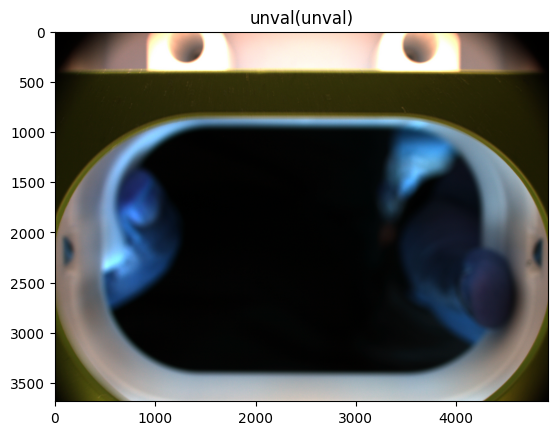

In [161]:
# random read
path = 'cyn'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
img = random.choice(imgs)
img = cv2.imread(os.path.join(path,label,img))
img_org = img.copy()

#predict
img = cv2.resize(img,(DIM,DIM), interpolation = cv2.INTER_AREA)
img = img/255.0
img = img.reshape(1,-1)
pred = loaded_model.predict(img)

plt.imshow(img_org)
title = dic[pred[0]]+"("+label+")"
plt.title(title)

# references

[sklearn_object_classification](https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/27_cell_classification/sklearn_object_classification.html)

[Image_Classification_using_SVM](https://github.com/aditi-govindu/Image-Classsification-using-sklearn/blob/main/Image_Classification_using_SVM.ipynb)

[image-classification-with-scikit-learn](https://kapernikov.com/tutorial-image-classification-with-scikit-learn/)